
# TASK 2 · Customer Segmentation Analysis

## Objective

Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

### Tech Stack
Python, pandas, scikit-learn (K-Means), matplotlib, seaborn, Jupyter Notebook

### Method
This project uses **RFM Analysis**:
- **Recency** – how recently a customer purchased
- **Frequency** – how often a customer placed orders
- **Monetary** – how much a customer spent

The RFM features are standardised using `StandardScaler` and then segmented using **K-Means clustering**.


## 1. Import Libraries

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Load Dataset

In [2]:

# Keep the Excel file in the same folder as this notebook
file_path = "Online_Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


## 3. Initial Dataset Inspection

In [3]:

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDataset Information:")
df.info()


Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:


,Data Type
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[us]
UnitPrice,float64
CustomerID,float64
Country,str



Missing Values:


,Missing Values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0



Duplicate Rows: 5268

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB



### Observation

The dataset contains transaction-level e-commerce records with invoice information, product details, quantity, unit price, customer ID, invoice date and country. `CustomerID` is important for customer-level segmentation, while `Quantity`, `UnitPrice` and `InvoiceDate` are required to construct the RFM features.


## 4. Data Cleaning and Data Quality Check

In [4]:

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Remove rows without CustomerID because customer segmentation requires a customer identifier
df = df.dropna(subset=["CustomerID"]).copy()

# Create transaction value
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Identify cancelled invoices
cancelled_invoices = df["InvoiceNo"].astype(str).str.startswith("C")

print("Rows after removing missing CustomerID:", len(df))
print("Cancelled invoice rows:", cancelled_invoices.sum())
print("Invalid InvoiceDate values:", df["InvoiceDate"].isna().sum())
print("Non-positive quantities:", (df["Quantity"] <= 0).sum())
print("Non-positive unit prices:", (df["UnitPrice"] <= 0).sum())


Rows after removing missing CustomerID: 406829
Cancelled invoice rows: 8905
Invalid InvoiceDate values: 0
Non-positive quantities: 8905
Non-positive unit prices: 40


In [5]:

# Keep completed sales transactions only
df_clean = df[
    (~cancelled_invoices) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (df["InvoiceDate"].notna())
].copy()

print("Cleaned dataset shape:", df_clean.shape)
display(df_clean.head())


Cleaned dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34



### Observation

Cancelled invoices and non-positive transactions are excluded because they do not represent normal completed purchases. Rows without `CustomerID` are also excluded because they cannot be assigned to a customer segment.


## 5. Descriptive Statistics

In [6]:

descriptive_stats = df_clean[["Quantity", "UnitPrice", "TotalPrice"]].describe().T
descriptive_stats = descriptive_stats.rename(columns={
    "count": "Count",
    "mean": "Mean",
    "std": "Std Dev",
    "min": "Min",
    "25%": "25%",
    "50%": "Median",
    "75%": "75%",
    "max": "Max"
})

display(descriptive_stats)


,Count,Mean,Std Dev,Min,25%,Median,75%,Max
Quantity,"397,884.00",12.99,179.33,1.00,2.00,6.00,12.00,"80,995.00"
UnitPrice,"397,884.00",3.12,22.10,0.00,1.25,1.95,3.75,"8,142.75"
TotalPrice,"397,884.00",22.40,309.07,0.00,4.68,11.80,19.80,"168,469.60"



### Observation

The transaction values are highly skewed because some customers place much larger orders than typical customers. This makes customer-level aggregation especially useful for segmentation.


## 6. Create RFM Features

In [7]:

# Use the day after the last transaction as the reference date
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print("Number of customers:", rfm.shape[0])
display(rfm.head())

print("\nRFM Descriptive Statistics:")
display(rfm[["Recency", "Frequency", "Monetary"]].describe().T)


Number of customers: 4338


,CustomerID,Recency,Frequency,Monetary
0,"12,346.00",326,1,"77,183.60"
1,"12,347.00",2,7,"4,310.00"
2,"12,348.00",75,4,"1,797.24"
3,"12,349.00",19,1,"1,757.55"
4,"12,350.00",310,1,334.40



RFM Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.00",92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,"4,338.00","2,054.27","8,989.23",3.75,307.41,674.49,"1,661.74","280,206.02"



### RFM Interpretation

- **Recency:** Lower values are better because they mean the customer purchased more recently.
- **Frequency:** Higher values indicate customers who order more often.
- **Monetary:** Higher values indicate customers who spend more.

These three behavioural features will be used for clustering.


## 7. RFM Distribution

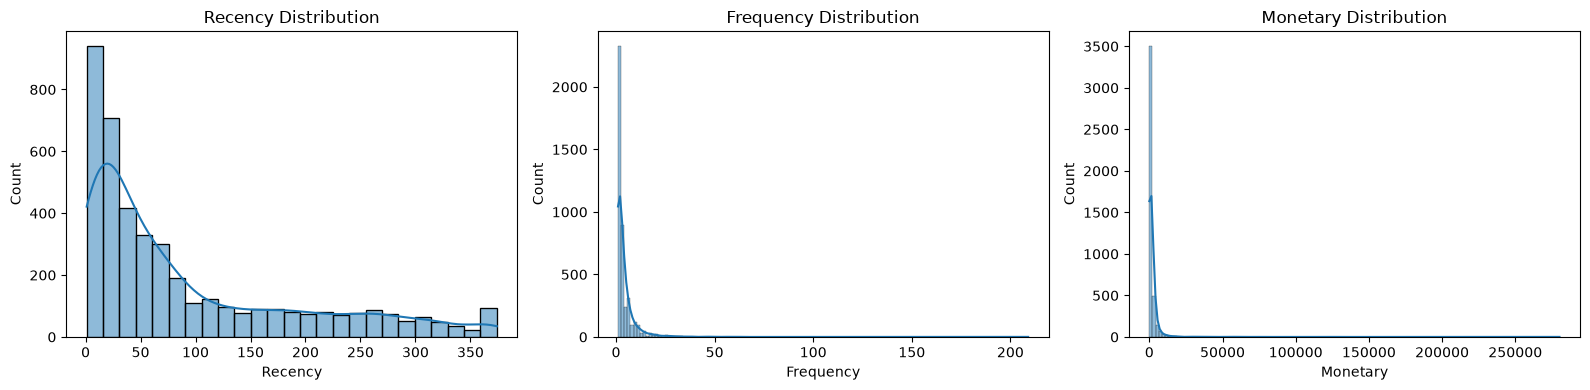

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()


## 8. Standardise RFM Features

In [9]:

features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=features,
    index=rfm.index
)

display(rfm_scaled_df.head())


,Recency,Frequency,Monetary
0,2.33,-0.43,8.36
1,-0.91,0.35,0.25
2,-0.18,-0.04,-0.03
3,-0.74,-0.43,-0.03
4,2.17,-0.43,-0.19



### Why StandardScaler?

RFM features are measured on very different scales. For example, Recency may be measured in days while Monetary can be measured in hundreds or thousands. `StandardScaler` puts the variables on a comparable scale so that K-Means is not dominated by a single feature.


## 9. Elbow Method to Determine Optimal K

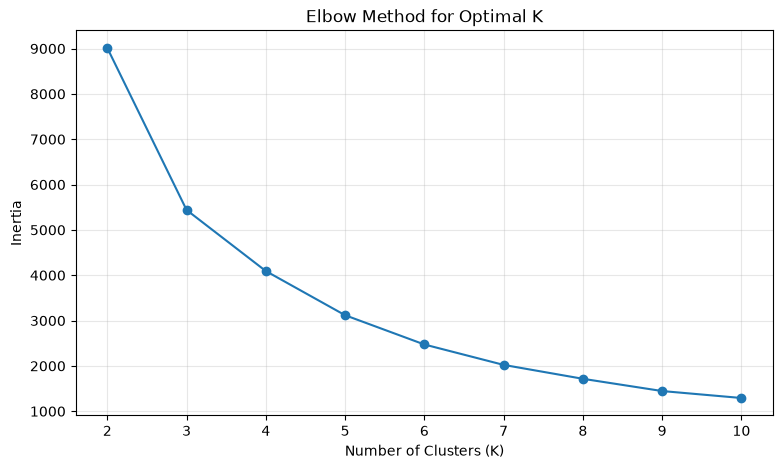

In [10]:

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()



### K Selection

The elbow curve typically shows a noticeable reduction in inertia up to around **K = 4**, after which the improvement becomes smaller. Therefore, **4 customer segments** are selected for the final K-Means model.

A silhouette score is also checked as a supporting metric.


In [11]:

silhouette_scores = {}

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(rfm_scaled)
    silhouette_scores[k] = silhouette_score(rfm_scaled, labels)

silhouette_df = pd.DataFrame({
    "K": list(silhouette_scores.keys()),
    "Silhouette Score": list(silhouette_scores.values())
})

display(silhouette_df)

best_k_by_silhouette = silhouette_df.loc[
    silhouette_df["Silhouette Score"].idxmax(), "K"
]

print("Best K by silhouette score:", int(best_k_by_silhouette))
print("Final K selected for this business segmentation:", 4)


,K,Silhouette Score
0,2,0.90
1,3,0.59
2,4,0.62
3,5,0.62
4,6,0.60
5,7,0.52
6,8,0.49


Best K by silhouette score: 2
Final K selected for this business segmentation: 4


## 10. Apply K-Means Clustering

In [12]:

final_k = 4

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed.")
display(rfm.head())


K-Means clustering completed.


,CustomerID,Recency,Frequency,Monetary,Cluster
0,"12,346.00",326,1,"77,183.60",3
1,"12,347.00",2,7,"4,310.00",0
2,"12,348.00",75,4,"1,797.24",0
3,"12,349.00",19,1,"1,757.55",0
4,"12,350.00",310,1,334.40,1


## 11. Profile Each Customer Cluster

In [13]:

cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).sort_values("Avg_Monetary", ascending=False)

cluster_profile["Customer_Percentage"] = (
    cluster_profile["Customers"] / len(rfm) * 100
)

cluster_profile = cluster_profile.round(2)

display(cluster_profile)


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage
Cluster,,,,,
2,13,7.38,82.54,"127,338.31",0.30
3,204,15.50,22.33,"12,709.09",4.70
0,3054,43.70,3.68,"1,359.05",70.40
1,1067,248.08,1.55,480.62,24.60



### Cluster Interpretation

The exact cluster numbers are arbitrary; the business meaning comes from their RFM profiles.

Typical customer types in this analysis are:

- **High-Value / VIP Customers:** very recent purchases, high frequency and high monetary value.
- **Loyal Customers:** recent purchases with relatively high purchase frequency and spending.
- **Regular Customers:** moderate purchasing activity and spending.
- **At-Risk / Dormant Customers:** long time since last purchase, low frequency and lower spending.

The next section automatically assigns business-friendly labels based on the calculated cluster profile.


In [14]:

# Assign business-friendly labels using the actual cluster averages
profile = cluster_profile.copy()

labels = {}

for cluster, row in profile.iterrows():
    if row["Avg_Recency"] <= 30 and row["Avg_Frequency"] >= 15 and row["Avg_Monetary"] >= 5000:
        labels[cluster] = "VIP / High-Value"
    elif row["Avg_Recency"] <= 60 and row["Avg_Frequency"] >= 3 and row["Avg_Monetary"] >= 1000:
        labels[cluster] = "Loyal Customers"
    elif row["Avg_Recency"] > 150:
        labels[cluster] = "At-Risk / Dormant"
    else:
        labels[cluster] = "Regular Customers"

rfm["Segment"] = rfm["Cluster"].map(labels)
cluster_profile["Segment"] = cluster_profile.index.map(labels)

display(cluster_profile.sort_values("Avg_Monetary", ascending=False))


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage,Segment
Cluster,,,,,,
2,13,7.38,82.54,"127,338.31",0.30,VIP / High-Value
3,204,15.50,22.33,"12,709.09",4.70,VIP / High-Value
0,3054,43.70,3.68,"1,359.05",70.40,Loyal Customers
1,1067,248.08,1.55,480.62,24.60,At-Risk / Dormant


## 12. Scatter Plot – Recency vs Monetary

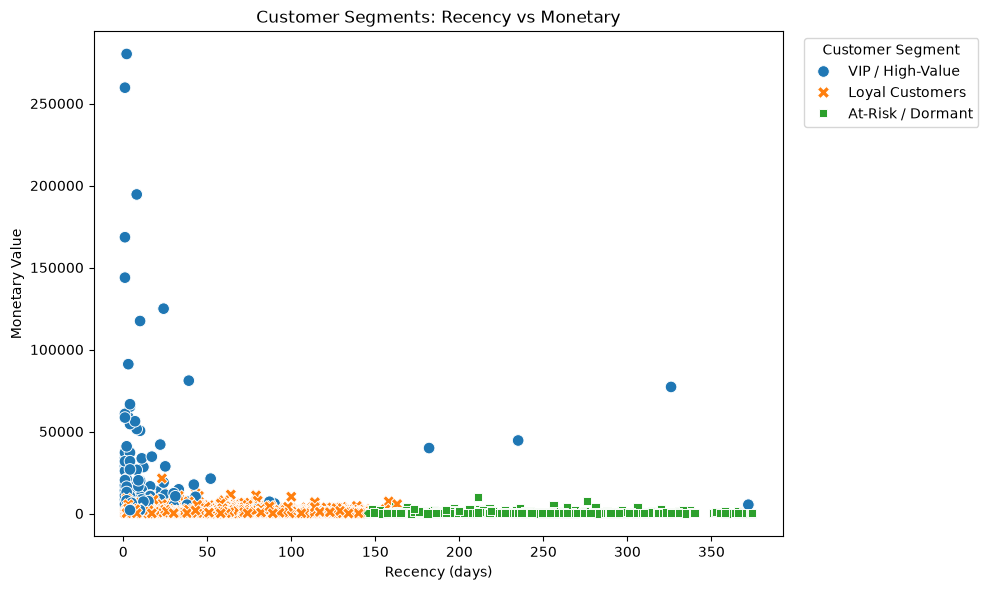

In [15]:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    style="Segment",
    s=70
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 13. Scatter Plot – Frequency vs Monetary

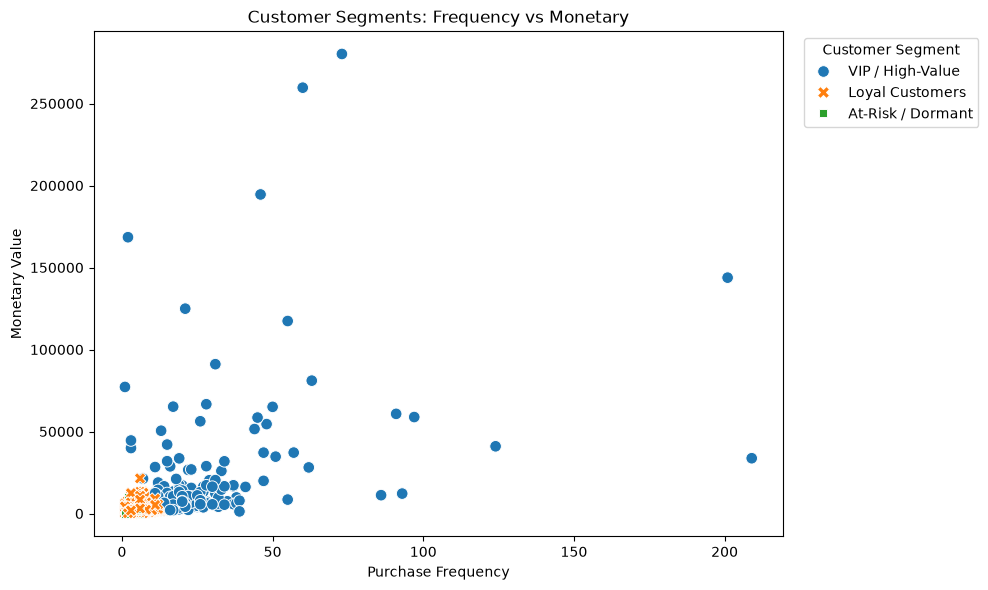

In [16]:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    style="Segment",
    s=70
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 14. Number of Customers per Cluster

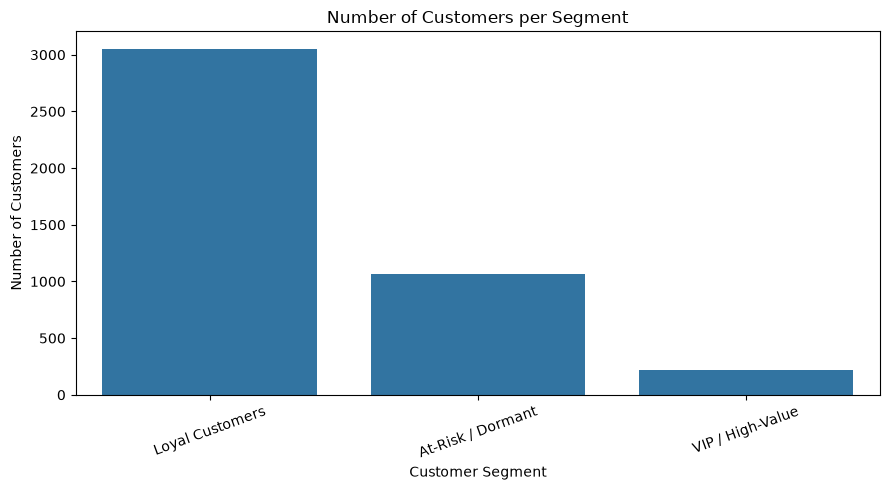

,Segment,Customers
0,Loyal Customers,3054
1,At-Risk / Dormant,1067
2,VIP / High-Value,217


In [17]:

cluster_counts = (
    rfm["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customers")
)

plt.figure(figsize=(9, 5))
sns.barplot(data=cluster_counts, x="Segment", y="Customers")
plt.title("Number of Customers per Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(cluster_counts)



## 15. Actionable Marketing Recommendations

### 1. VIP / High-Value Customers
Provide premium loyalty rewards, early access to new products, exclusive offers and personalised recommendations. These customers generate the highest value and should be retained carefully.

### 2. Loyal Customers
Use loyalty programmes, cross-selling and bundle offers to increase their average order value. Personalised recommendations can encourage repeat purchases.

### 3. Regular Customers
Use targeted promotions, product recommendations and limited-time offers to increase purchase frequency and move these customers toward the loyal segment.

### 4. At-Risk / Dormant Customers
Run win-back campaigns such as personalised discounts, reminder emails and special reactivation offers. The goal is to bring recently inactive customers back before they become permanently lost.



## 16. Conclusion

The customer base was segmented using **RFM analysis and K-Means clustering**.

The analysis first cleaned transaction data by handling missing customer identifiers, cancelled invoices and invalid transactions. Customer-level **Recency, Frequency and Monetary** features were then created and standardised using `StandardScaler`.

The **Elbow Method** was used to select a practical value of **K = 4**, producing four behavioural customer groups. The resulting segments can support targeted marketing rather than treating all customers in the same way.

Overall, the segmentation helps the business:
- retain high-value customers,
- strengthen loyalty among frequent buyers,
- increase spending from regular customers,
- and reactivate at-risk or dormant customers.

This provides a data-driven basis for customer relationship management and targeted marketing campaigns.



---

### Final Project Note

**RFM definitions used in this project:**

- `Recency = days since the customer's most recent purchase`
- `Frequency = number of unique invoices/orders`
- `Monetary = total customer spending`

**Revenue per transaction:**

`TotalPrice = Quantity × UnitPrice`

The notebook is designed so that the Excel dataset and this notebook can be kept in the same folder and executed directly in Jupyter Notebook or VS Code.
